# Workshop: vlastný model na dofarbovanie čiernobielych fotografií

Cieľ notebooku je natrénovať jednoduchý vlastný neurónový model na úlohu **image colorization**.

Pipeline:

1. načítam farebné obrázky z datasetu,
2. z farebných obrázkov vytvorím čiernobiely vstup,
3. model dostane grayscale obrázok a učí sa predikovať farebný RGB obrázok,
4. výsledok ukážem na 10 obrázkoch,
5. uložím výstupy pre 5-slidovú prezentáciu.

Toto je vlastný trénovaný model, nie hotový stiahnutý predtrénovaný model.


In [25]:
from pathlib import Path
import random
import time
import math

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch: 2.12.1+cpu
CUDA available: False


## 1. Nastavenie ciest a hyperparametrov

Ak chceš rýchly test, nechaj menší počet obrázkov a epoch.  
Ak chceš lepší výsledok, zvýš `MAX_IMAGES` a `EPOCHS`.


In [26]:
# Notebook môže byť spustený buď z root priečinka projektu, alebo z priečinka notebooks.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample_color"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
COLORIZED_DIR = OUTPUT_DIR / "colorized"
COMPARISON_DIR = OUTPUT_DIR / "comparisons"
CHECKPOINT_DIR = PROJECT_ROOT / "models" / "own_colorization"

for p in [OUTPUT_DIR, COLORIZED_DIR, COMPARISON_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Rýchle a obhájiteľné nastavenie pre školský workshop.
IMAGE_SIZE = 96
MAX_IMAGES = 800        # môžeš zvýšiť napr. na 1500 alebo 3000, ak máš čas
BATCH_SIZE = 16
EPOCHS = 10             # môžeš zvýšiť napr. na 20
LEARNING_RATE = 1e-3
SEED = 42
NUM_WORKERS = 0         # na Windows nechaj 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("SAMPLE_DIR:", SAMPLE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Device:", DEVICE)


PROJECT_ROOT: d:\unicorn\mml_workshop
DATASET_DIR: d:\unicorn\mml_workshop\data\dataset
SAMPLE_DIR: d:\unicorn\mml_workshop\data\sample_color
OUTPUT_DIR: d:\unicorn\mml_workshop\outputs
Device: cpu


## 2. Načítanie datasetu

Použijem farebné obrázky, pretože z nich viem automaticky vytvoriť dvojice:

- vstup modelu: čiernobiely obrázok,
- target: pôvodný farebný obrázok.

To je supervised learning, pretože pre každý vstup existuje očakávaný výstup.


In [27]:
def collect_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in exts])

all_image_paths = collect_images(DATASET_DIR)
if len(all_image_paths) == 0:
    all_image_paths = collect_images(SAMPLE_DIR)

print("Found images:", len(all_image_paths))

if len(all_image_paths) == 0:
    raise FileNotFoundError("Nenašli sa žiadne obrázky. Skontroluj data/dataset alebo data/sample_color.")

random.shuffle(all_image_paths)
image_paths = all_image_paths[:min(MAX_IMAGES, len(all_image_paths))]

print("Used images:", len(image_paths))
print("First files:")
for p in image_paths[:5]:
    print(" -", p.name)


Found images: 4319
Used images: 800
First files:
 - 00000430_(3).jpg
 - 00000673_(2).jpg
 - 00000845_(2).jpg
 - 00000621_(2).jpg
 - 00000281.jpg


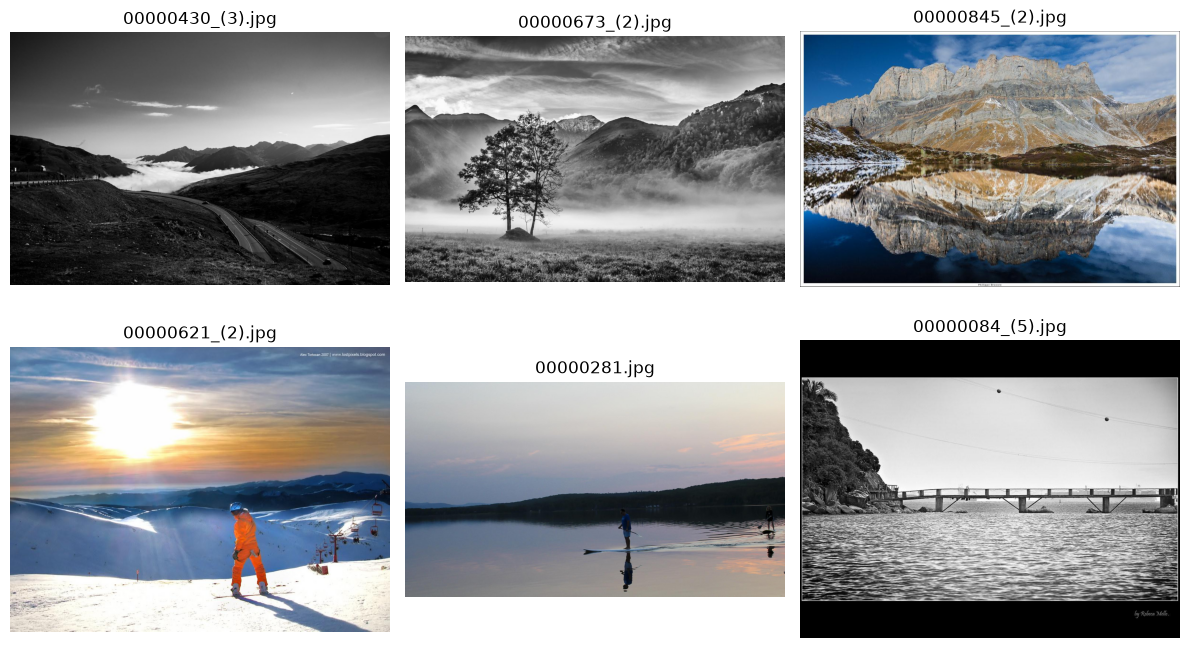

In [28]:
# Ukážka niekoľkých farebných obrázkov z datasetu
sample_paths = image_paths[:6]

plt.figure(figsize=(12, 7))
for i, path in enumerate(sample_paths):
    img = Image.open(path).convert("RGB")
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(path.name)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 3. Dataset trieda

Model bude mať:

- **input**: grayscale tensor s tvarom `[1, H, W]`,
- **target**: RGB tensor s tvarom `[3, H, W]`.

Obrázky sú škálované do rozsahu `[0, 1]`.


In [29]:
class ColorizationDataset(Dataset):
    def __init__(self, image_paths, image_size=96):
        self.image_paths = list(image_paths)

        self.to_rgb_tensor = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

        self.to_gray_tensor = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")

        gray = self.to_gray_tensor(img)
        rgb = self.to_rgb_tensor(img)

        return gray, rgb, path.name


dataset = ColorizationDataset(image_paths, image_size=IMAGE_SIZE)

train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_ds, test_ds = random_split(dataset, [train_size, test_size], generator=generator)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Train images:", len(train_ds))
print("Test images:", len(test_ds))


Train images: 680
Test images: 120


Gray batch: torch.Size([16, 1, 96, 96])
RGB batch: torch.Size([16, 3, 96, 96])


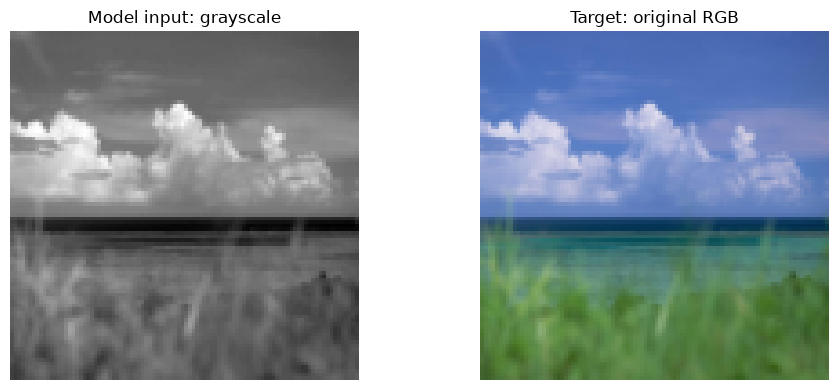

In [30]:
# Kontrola jedného batchu
gray_batch, rgb_batch, names = next(iter(train_loader))

print("Gray batch:", gray_batch.shape)
print("RGB batch:", rgb_batch.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray_batch[0].permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Model input: grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rgb_batch[0].permute(1, 2, 0))
plt.title("Target: original RGB")
plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Model: jednoduchý CNN encoder-decoder so skip connection

Použijem malý vlastný model podobný zjednodušenému U-Netu.

Prečo tento typ modelu:

- CNN vie pracovať s priestorovou štruktúrou obrazu,
- encoder zmenšuje rozmer a učí sa reprezentáciu,
- decoder rekonštruuje farebný obrázok,
- skip connection pomáha zachovať hrany a lokálne detaily.


In [31]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SmallUNetColorizer(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(64, 128)

        # Decoder
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = ConvBlock(128 + 64, 64)

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = ConvBlock(64 + 32, 32)

        self.out = nn.Sequential(
            nn.Conv2d(32, 3, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        x = self.pool1(e1)

        e2 = self.enc2(x)
        x = self.pool2(e2)

        x = self.bottleneck(x)

        x = self.up2(x)
        x = torch.cat([x, e2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, e1], dim=1)
        x = self.dec1(x)

        return self.out(x)


model = SmallUNetColorizer().to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("Parameters:", num_params)
print("Trainable parameters:", trainable_params)


SmallUNetColorizer(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)


## 5. Tréning

Použijem `L1Loss`, pretože pri rekonštrukcii obrazu často dáva menej rozmazané výsledky ako MSE.  
Model sa učí minimalizovať rozdiel medzi predikovaným RGB obrázkom a pôvodným farebným obrázkom.


In [32]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "test_loss": []
}

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for gray, rgb, _ in loader:
            gray = gray.to(DEVICE)
            rgb = rgb.to(DEVICE)

            pred = model(gray)
            loss = criterion(pred, rgb)

            batch_size = gray.size(0)
            total_loss += loss.item() * batch_size
            total_items += batch_size

    return total_loss / max(total_items, 1)


start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_items = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)

    for gray, rgb, _ in progress:
        gray = gray.to(DEVICE)
        rgb = rgb.to(DEVICE)

        optimizer.zero_grad()
        pred = model(gray)
        loss = criterion(pred, rgb)
        loss.backward()
        optimizer.step()

        batch_size = gray.size(0)
        running_loss += loss.item() * batch_size
        running_items += batch_size

        progress.set_postfix(loss=loss.item())

    train_loss = running_loss / max(running_items, 1)
    test_loss = evaluate(model, test_loader)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train L1: {train_loss:.4f} | test L1: {test_loss:.4f}")

elapsed = time.time() - start_time
print(f"Training finished in {elapsed/60:.1f} minutes.")


Epoch 1/10:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 01/10 | train L1: 0.1402 | test L1: 0.0835


Epoch 2/10:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 02/10 | train L1: 0.0778 | test L1: 0.0731


Epoch 3/10:   0%|          | 0/43 [00:00<?, ?it/s]

...

Epoch 08/10 | train L1: 0.0643 | test L1: 0.0609


Epoch 9/10:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 09/10 | train L1: 0.0629 | test L1: 0.0578


Epoch 10/10:   0%|          | 0/43 [00:00<?, ?it/s]

Epoch 10/10 | train L1: 0.0625 | test L1: 0.0613
Training finished in 7.4 minutes.


In [33]:
# Uloženie modelu
checkpoint_path = CHECKPOINT_DIR / "small_unet_colorizer.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "image_size": IMAGE_SIZE,
    "max_images": MAX_IMAGES,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "history": history,
}, checkpoint_path)

print("Saved model checkpoint to:", checkpoint_path)


Saved model checkpoint to: d:\unicorn\mml_workshop\models\own_colorization\small_unet_colorizer.pth


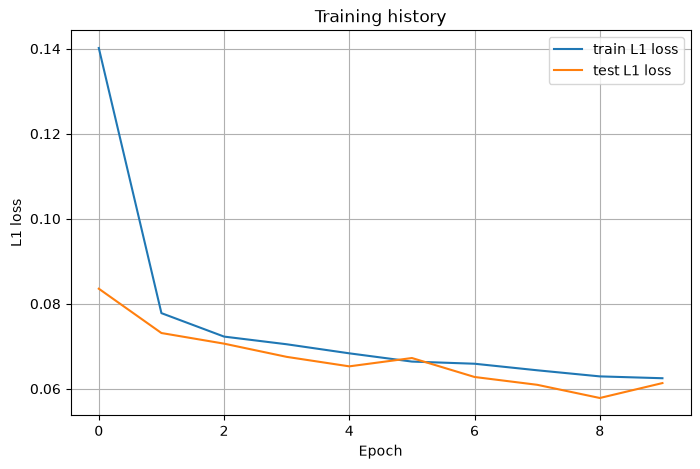

Saved loss plot to: d:\unicorn\mml_workshop\outputs\training_loss.png


In [34]:
# Graf loss počas tréningu
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train L1 loss")
plt.plot(history["test_loss"], label="test L1 loss")
plt.xlabel("Epoch")
plt.ylabel("L1 loss")
plt.title("Training history")
plt.legend()
plt.grid(True)

loss_plot_path = OUTPUT_DIR / "training_loss.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved loss plot to:", loss_plot_path)


## 6. Výsledky na 10 obrázkoch

Prezentácia má ukázať výsledok na 10 obrázkoch.  
Každý výstup obsahuje:

1. pôvodný farebný obrázok,
2. čiernobiely vstup,
3. dofarbený výstup modelu.


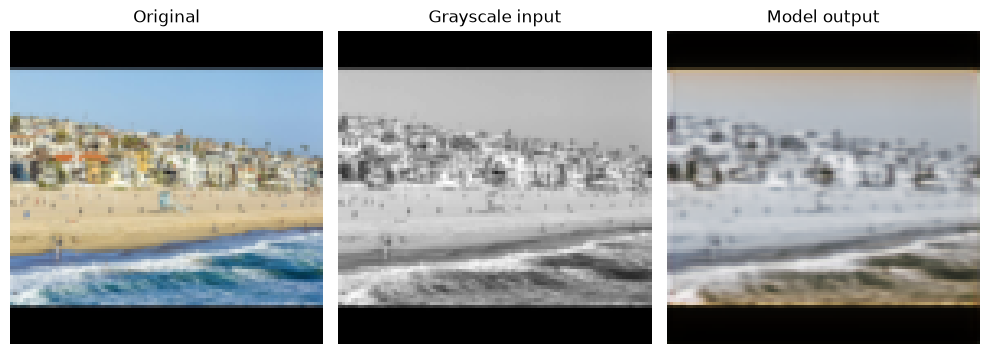

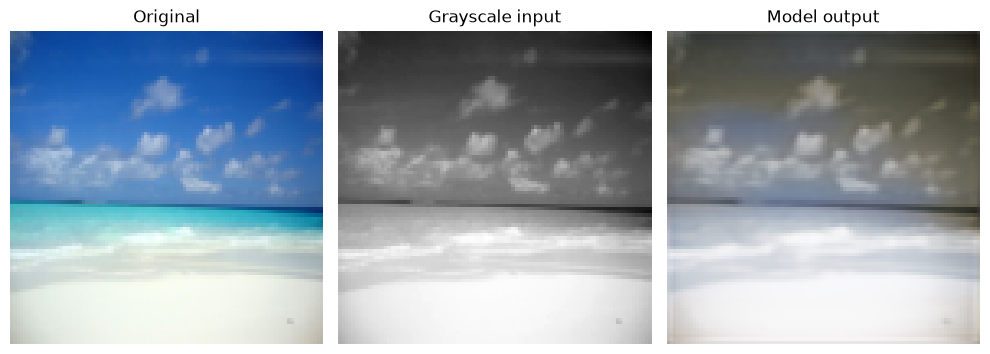

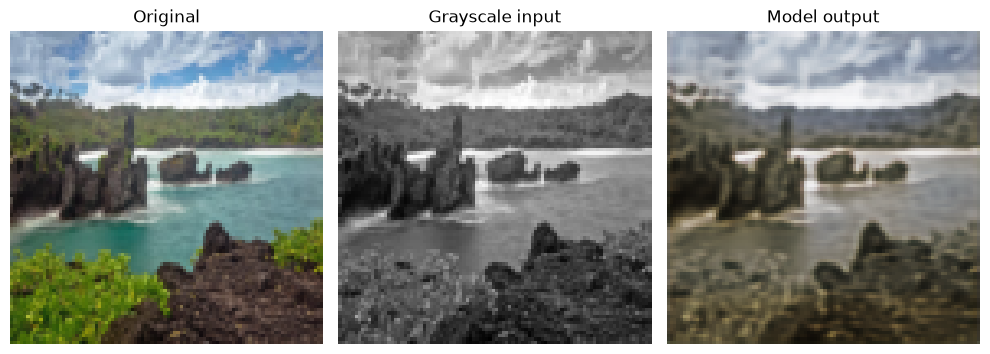

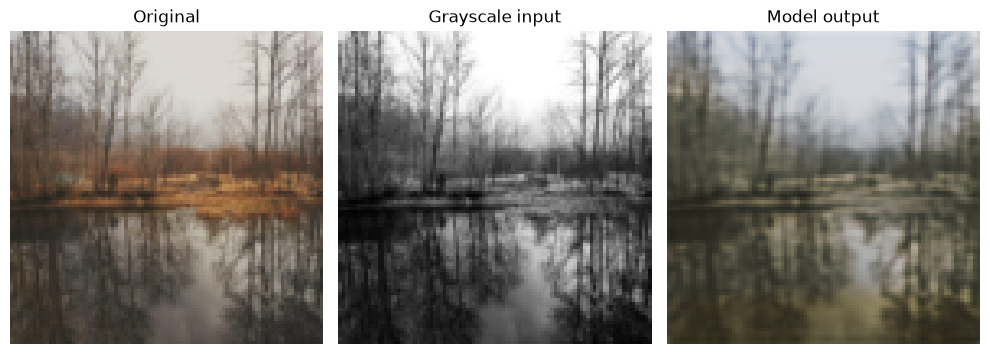

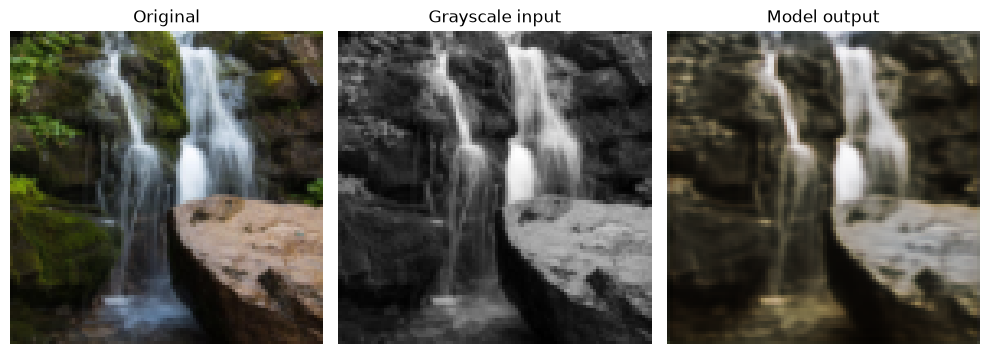

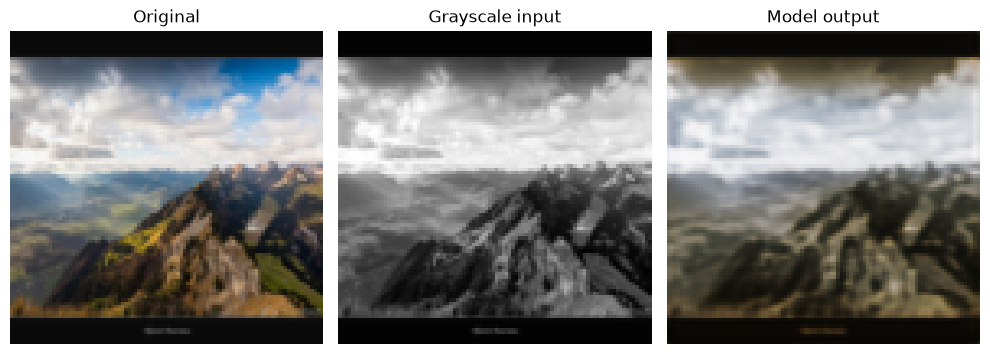

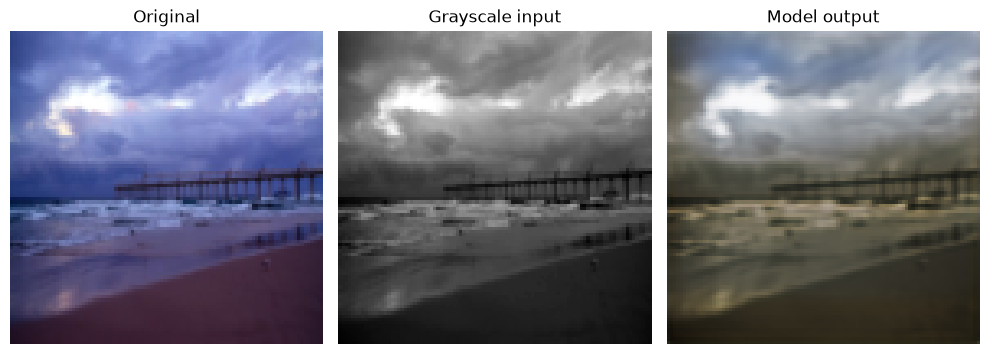

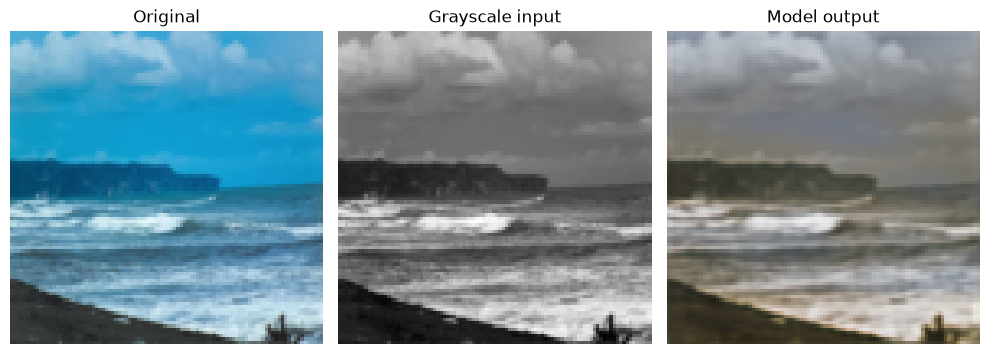

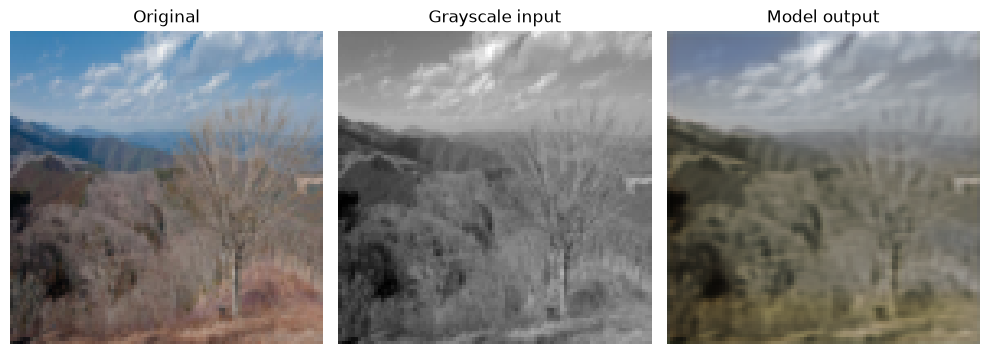

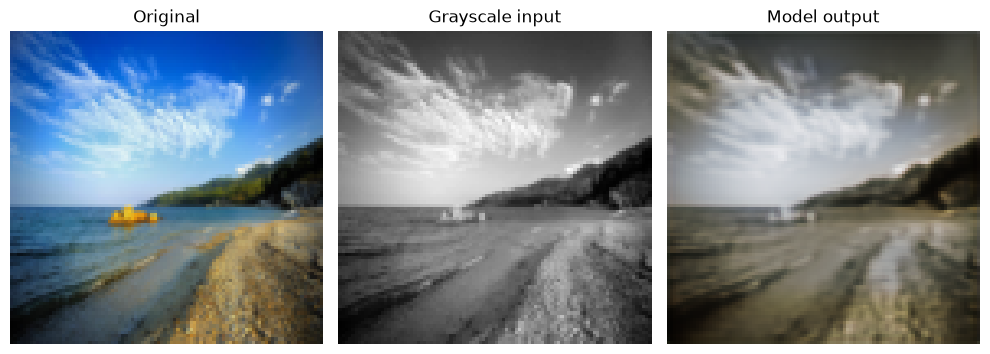

Saved 10 result comparisons.
Colorized outputs: d:\unicorn\mml_workshop\outputs\colorized
Comparisons: d:\unicorn\mml_workshop\outputs\comparisons


In [35]:
def tensor_to_image(tensor):
    # tensor: [C, H, W], values 0..1
    tensor = tensor.detach().cpu().clamp(0, 1)
    arr = tensor.permute(1, 2, 0).numpy()
    arr = (arr * 255).astype(np.uint8)
    return Image.fromarray(arr)

def gray_tensor_to_image(tensor):
    tensor = tensor.detach().cpu().clamp(0, 1)
    arr = tensor.squeeze(0).numpy()
    arr = (arr * 255).astype(np.uint8)
    return Image.fromarray(arr, mode="L")

def save_comparison(gray, pred, target, name, index):
    gray_img = gray_tensor_to_image(gray)
    pred_img = tensor_to_image(pred)
    target_img = tensor_to_image(target)

    pred_path = COLORIZED_DIR / f"{index:02d}_{Path(name).stem}_colorized.png"
    cmp_path = COMPARISON_DIR / f"{index:02d}_{Path(name).stem}_comparison.png"

    pred_img.save(pred_path)

    fig = plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(target_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gray_img, cmap="gray")
    plt.title("Grayscale input")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_img)
    plt.title("Model output")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(cmp_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return pred_path, cmp_path


model.eval()

saved = []
count = 0

with torch.no_grad():
    for gray_batch, rgb_batch, names in test_loader:
        gray_batch = gray_batch.to(DEVICE)
        rgb_batch = rgb_batch.to(DEVICE)

        pred_batch = model(gray_batch)

        for i in range(gray_batch.size(0)):
            if count >= 10:
                break

            pred_path, cmp_path = save_comparison(
                gray_batch[i],
                pred_batch[i],
                rgb_batch[i],
                names[i],
                count + 1
            )

            saved.append((pred_path, cmp_path))
            count += 1

        if count >= 10:
            break

print(f"Saved {len(saved)} result comparisons.")
print("Colorized outputs:", COLORIZED_DIR)
print("Comparisons:", COMPARISON_DIR)


In [36]:
# Kontrola počtu uložených výstupov
colorized_count = len(list(COLORIZED_DIR.glob("*.png")))
comparison_count = len(list(COMPARISON_DIR.glob("*.png")))

print("Colorized image count:", colorized_count)
print("Comparison image count:", comparison_count)


Colorized image count: 10
Comparison image count: 10


## 7. Krátke zhodnotenie

Doplň podľa reálnych výsledkov po spustení notebooku.


In [37]:
final_train_loss = history["train_loss"][-1]
final_test_loss = history["test_loss"][-1]

summary = f'''
Zhrnutie experimentu:

- Použitý dataset: {len(image_paths)} farebných obrázkov.
- Trénovací set: {len(train_ds)} obrázkov.
- Testovací set: {len(test_ds)} obrázkov.
- Vstup modelu: grayscale obrázok s 1 kanálom.
- Výstup modelu: RGB obrázok s 3 kanálmi.
- Architektúra: jednoduchý CNN encoder-decoder so skip connections.
- Loss funkcia: L1 loss.
- Počet epoch: {EPOCHS}.
- Finálny train loss: {final_train_loss:.4f}.
- Finálny test loss: {final_test_loss:.4f}.
- Výsledky boli uložené do outputs/colorized a outputs/comparisons.

Interpretácia:
Model sa naučil základnú transformáciu z čiernobieleho vstupu na farebný výstup.
Výsledky môžu byť menej sýte alebo nie vždy farebne presné, pretože dofarbovanie je nejednoznačná úloha:
z jednej grayscale fotografie sa nedá jednoznačne určiť pôvodná farba objektov.
'''
print(summary)

summary_path = OUTPUT_DIR / "experiment_summary.txt"
summary_path.write_text(summary, encoding="utf-8")
print("Saved summary to:", summary_path)



Zhrnutie experimentu:

- Použitý dataset: 800 farebných obrázkov.
- Trénovací set: 680 obrázkov.
- Testovací set: 120 obrázkov.
- Vstup modelu: grayscale obrázok s 1 kanálom.
- Výstup modelu: RGB obrázok s 3 kanálmi.
- Architektúra: jednoduchý CNN encoder-decoder so skip connections.
- Loss funkcia: L1 loss.
- Počet epoch: 10.
- Finálny train loss: 0.0625.
- Finálny test loss: 0.0613.
- Výsledky boli uložené do outputs/colorized a outputs/comparisons.

Interpretácia:
Model sa naučil základnú transformáciu z čiernobieleho vstupu na farebný výstup.
Výsledky môžu byť menej sýte alebo nie vždy farebne presné, pretože dofarbovanie je nejednoznačná úloha:
z jednej grayscale fotografie sa nedá jednoznačne určiť pôvodná farba objektov.

Saved summary to: d:\unicorn\mml_workshop\outputs\experiment_summary.txt


## 8. Body do 5-slidovej prezentácie

**Slide 1 – Zadanie a cieľ**  
Dofarbiť čiernobiele fotografie pomocou vlastného natrénovaného modelu.

**Slide 2 – Dataset a príprava dát**  
Použil som farebné obrázky, z ktorých som vytvoril grayscale vstupy. Pôvodné RGB obrázky slúžili ako target.

**Slide 3 – Model**  
Jednoduchý CNN encoder-decoder / mini U-Net: grayscale vstup → latentná reprezentácia → RGB výstup.

**Slide 4 – Výsledky**  
Ukážka 10 obrázkov: original / grayscale / model output.

**Slide 5 – Záver a limity**  
Model funguje ako základná colorization pipeline, ale farby nemusia byť fakticky správne. Úloha je nejednoznačná a lepší výsledok by vyžadoval väčší dataset, dlhší tréning alebo silnejšiu architektúru.
